In [4]:
from earthscope_sfg_workflows.workflows.workflow_handler import WorkflowHandler
from earthscope_sfg_tools.tiledb_integration import TDBGNSSObsArray

import tiledb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#source directory for files to validate
source_dir = Path("/Users/mikegottlieb/data/sfg/validate_these")   

# Main working directory for all data operations
main_dir = Path("/Users/mikegottlieb/data/sfg_validation")

# Network, station, and campaign identifiers
NETWORK = "cascadia-gorda"
STATION = "SLT1"
CAMPAIGN = "2026_A_1126"


In [5]:
workflow = WorkflowHandler(directory=main_dir)
workflow.set_network_station_campaign(network_id=NETWORK, station_id=STATION, campaign_id=CAMPAIGN)

sv3 = workflow._session.pipeline.get_sv3()

/Users/mikegottlieb/GIT/earthscope-sfg-workflows/src/earthscope_sfg_workflows/workflows/workspace.py:88: UserWarning: Environment variable S3_SYNC_BUCKET is not set.
  Environment.load_working_environment()
Active context: cascadia-gorda / SLT1 / 2026_A_1126


## Ingest raw files
`ingest_add_local_data` catalogs everything it recognizes in a *directory* (no single-file option), so to validate just these three named files - rather than the whole campaign's `raw/` dir - stage symlinks to them in an isolated subdirectory first.

In [6]:
report = workflow._session.ingest.local(source_dir=source_dir)
print(report)

IngestReport(cataloged=2, downloaded=0, skipped=0, errors=())


## Process raw files
`process_novatel` parses both NOV000 and NOV770 in one pass (writes to `imu_position.tdb` / `gnss_obs_secondary.tdb` and `gnss_obs.tdb` respectively - there's no separate per-format job); `process_dfop00` parses the acoustic file into `shotdata_pre.tdb`.

In [7]:
workflow.preprocess_run_pipeline_sv3(job="process_novatel")


Processing 1 Novatel 770 files for cascadia-gorda SLT1 2026_A_1126. This may take a few minutes...
Running sfg novab2tile: /Users/mikegottlieb/GIT/earthscope-sfg-workflows/.pixi/envs/geolab/lib/python3.12/site-packages/earthscope_sfg_tools/go/build/sfg_darwin_arm64 novab2tile --tdb /Users/mikegottlieb/data/sfg_validation/cascadia-gorda/SLT1/TileDB/gnss_obs.tdb --procs 14 /Users/mikegottlieb/data/sfg/validate_these/341517_001_20260603_095437_00046_NOV770.raw
time="2026-08-14T06:48:14-07:00" level=info msg="Num procs: 14"
2026/08/14 06:48:14 INFO Copying schema from source array source=s3://earthscope-tiledb-schema-dev-us-east-2-ebamji/GNSS_OBS_SCHEMA_V3.tdb/
2026/08/14 06:48:14 INFO Creating array at destination destination=/Users/mikegottlieb/data/sfg_validation/cascadia-gorda/SLT1/TileDB/gnss_obs.tdb
2026/08/14 06:48:15 WARN Checksum mismatch received=84001318 calculated=d9036eb1
2026/08/14 06:48:15 WARN Checksum mismatch received=84001318 calculated=8862ef7a
2026/08/14 06:48:15 WARN 

In [ ]:
workflow.preprocess_run_pipeline_sv3(job="process_dfop00")


## Completeness checks
Same idea for all three arrays: how many records actually landed vs. how many should have, given the data's own nominal sample interval. Rather than hardcode an assumed logging rate (easy to get wrong per receiver/config), the nominal interval is auto-detected as the mode of the observed time gaps - print it and sanity check it against whatever rate you configured on the receiver.

In [8]:
def plot_completeness(times, label, bin_minutes=1):
    """Records-per-bin vs expected, plus a gap-size histogram, for a series of timestamps."""
    times = pd.Series(sorted(pd.to_datetime(pd.Series(times))))
    if len(times) < 2:
        print(f"{label}: not enough records ({len(times)}) to assess completeness")
        return

    diffs = times.diff().dt.total_seconds().dropna()
    nominal_interval_s = diffs.mode().iloc[0]
    print(f"{label}: auto-detected nominal interval = {nominal_interval_s:.4f} s "
          f"({1 / nominal_interval_s:.2f} Hz)")

    counts = pd.Series(1, index=pd.DatetimeIndex(times)).resample(f"{bin_minutes}min").count()
    expected_per_bin = bin_minutes * 60 / nominal_interval_s

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(counts.index, counts.values, width=bin_minutes / 1440, align="edge", color="steelblue")
    axes[0].axhline(expected_per_bin, color="red", linestyle="--", label=f"expected ~{expected_per_bin:.0f}/bin")
    axes[0].set_title(f"{label}: records per {bin_minutes}-min bin")
    axes[0].set_ylabel("count")
    axes[0].legend()

    gap_thresh = nominal_interval_s * 1.5
    big_gaps = diffs[diffs > gap_thresh]
    axes[1].hist(big_gaps, bins=50, color="indianred")
    axes[1].set_title(f"{label}: gaps > {gap_thresh:.2f}s (n={len(big_gaps)})")
    axes[1].set_xlabel("gap (s)")
    fig.tight_layout()
    plt.show()

    total = len(times)
    duration_s = (times.iloc[-1] - times.iloc[0]).total_seconds()
    expected_total = duration_s / nominal_interval_s
    print(f"{label}: {total} records over {duration_s / 60:.1f} min "
          f"= {100 * total / expected_total:.1f}% of ~{expected_total:.0f} expected\n")

### GNSS observations (from NOV770 -> `gnss_obs.tdb`)

GNSS observations (NOV770): auto-detected nominal interval = 0.2000 s (5.00 Hz)


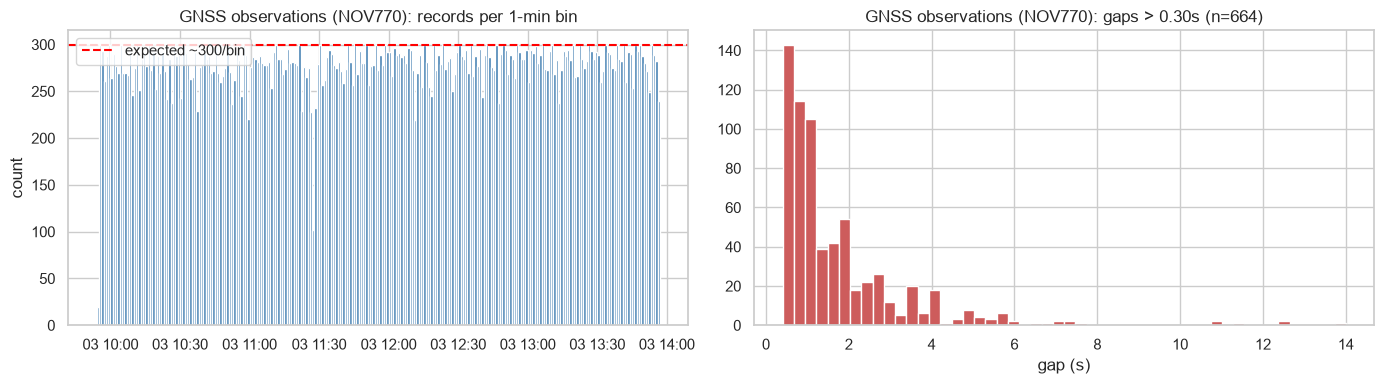

GNSS observations (NOV770): 67475 records over 241.9 min = 93.0% of ~72559 expected



In [9]:
def read_gnss_obs_times(uri):
    """gnss_obs.tdb's 'time' dimension is int64 ms-since-epoch (see the
    write_epochs docstring on TDBGNSSObsArray), not a datetime64 TileDB
    dimension - the base class's read_df() always slices with np.datetime64
    bounds, which TileDB can't cast against an int64 dim. Read the raw
    dimension directly instead, the same way get_unique_dates() does.

    One row per (sys, sat, obs) per epoch, so raw values repeat the same
    timestamp many times per epoch - dedupe to unique epoch times, or the
    mode of consecutive diffs locks onto 0 (same-epoch rows) instead of the
    real inter-epoch interval."""
    with tiledb.open(str(uri), mode="r") as array:
        time_ms = array[:]["time"]
    return pd.to_datetime(pd.Series(time_ms).unique(), unit="ms", utc=True)

gnss_times = read_gnss_obs_times(sv3.gnssObsTDBURI)
plot_completeness(gnss_times, "GNSS observations (NOV770)")

### IMU data (from NOV000 -> `imu_position.tdb`)
NOV000 also feeds a secondary `gnss_obs_secondary.tdb`; check that too if you care about NOV000's own GNSS channel separately from NOV770's.

IMU position (NOV000): auto-detected nominal interval = 0.0500 s (20.00 Hz)


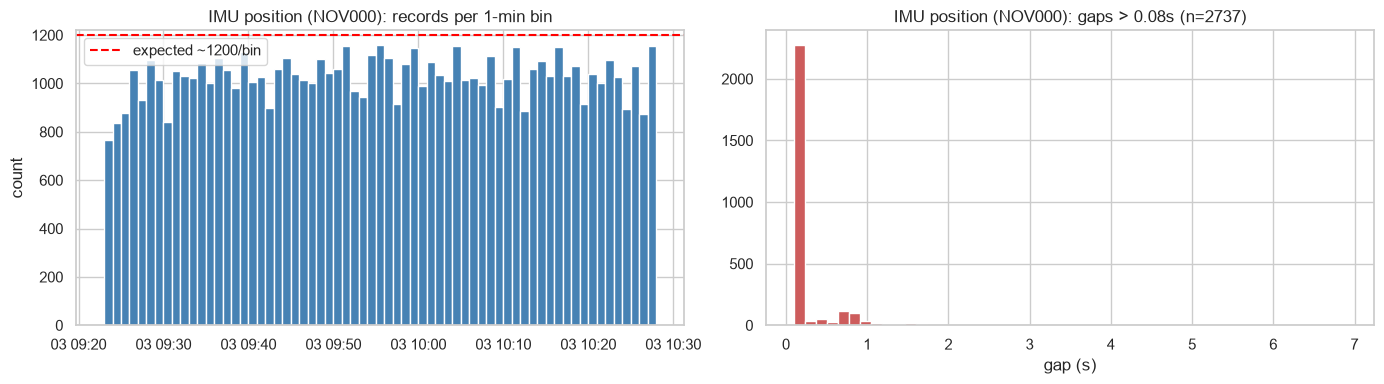

IMU position (NOV000): 66721 records over 64.8 min = 85.9% of ~77709 expected

GNSS observations, secondary (NOV000): auto-detected nominal interval = 2.2000 s (0.45 Hz)


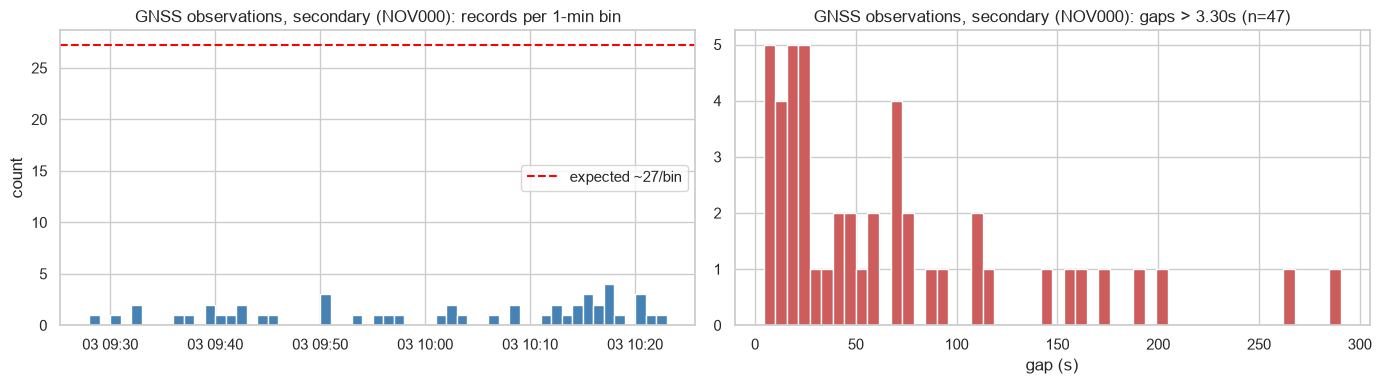

GNSS observations, secondary (NOV000): 49 records over 54.0 min = 3.3% of ~1473 expected



In [10]:
imu_dates = sv3.imuPositionTDB.get_unique_dates()  # field defaults to "time"
# get_unique_dates() truncates to day precision, so for a single-day file
# min()==max() - passing that through unchanged makes read_df's slice
# zero-width (it returns nothing, and its df.empty fallback is a bare
# pd.DataFrame() with no "time" column at all -> KeyError). Extend end to
# one day past the max so the window actually covers real timestamps,
# whether the data spans one day or several.
imu_start = pd.Timestamp(imu_dates.min()).to_pydatetime()
imu_end = (pd.Timestamp(imu_dates.max()) + pd.Timedelta(days=1)).to_pydatetime()
imu_df = sv3.imuPositionTDB.read_df(start=imu_start, end=imu_end)

plot_completeness(imu_df["time"], "IMU position (NOV000)")

# NOV000's own GNSS channel, separate from NOV770's primary gnss_obs.tdb above
sec_times = read_gnss_obs_times(sv3.gnssObsTDB_secondaryURI)
if len(sec_times):
    plot_completeness(sec_times, "GNSS observations, secondary (NOV000)")

### Acoustic data (from DFOP00 -> `shotdata_pre.tdb`)
Pings, not a fixed clock - so "nominal interval" here is the ping interval, and it's pooled across all transponders. For a per-transponder reply-count breakdown later in the pipeline (post GARPOS merge), see `workflow.modeling_plot_shotdata_replies_per_transponder()`.

In [ ]:
acoustic_dates = sv3.shotDataPreTDB.get_unique_dates()  # field defaults to "pingTime"
# same day-truncation issue as imu_dates above - extend end past the max day.
acoustic_start = pd.Timestamp(acoustic_dates.min()).to_pydatetime()
acoustic_end = (pd.Timestamp(acoustic_dates.max()) + pd.Timedelta(days=1)).to_pydatetime()
acoustic_df = sv3.shotDataPreTDB.read_df(start=acoustic_start, end=acoustic_end)

# One row per (ping, transponderID) reply - a ping to 3 transponders means 3 rows
# sharing the same pingTime, so raw diffs are dominated by 0s. Dedupe to unique
# ping events first, same fix as read_gnss_obs_times() above.
ping_times = pd.Series(acoustic_df["pingTime"]).unique()
plot_completeness(ping_times, "Acoustic pings (DFOP00)")

In [ ]:
transponder_ids = sorted(acoustic_df["transponderID"].unique())
n_transponders = len(transponder_ids)

replies_per_ping = acoustic_df.groupby("pingTime")["transponderID"].nunique()
replies_per_ping.index = pd.to_datetime(pd.Series(replies_per_ping.index))  # same conversion plot_completeness uses

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(replies_per_ping, bins=range(0, n_transponders + 2), align="left", color="steelblue", rwidth=0.8)
axes[0].set_xlabel("Replies received")
axes[0].set_ylabel("Number of pings")
axes[0].set_title("Replies per ping")

axes[1].scatter(replies_per_ping.index, replies_per_ping.values, s=5, color="steelblue")
axes[1].axhline(n_transponders, color="red", linestyle="--", label=f"all {n_transponders} transponders")
axes[1].set_xlabel("Ping time")
axes[1].set_ylabel("Replies received")
axes[1].set_title("Replies per ping over time")
axes[1].legend()
fig.tight_layout()
plt.show()

incomplete = replies_per_ping[replies_per_ping < n_transponders]
print(f"Transponders seen: {transponder_ids}")
print(f"{len(replies_per_ping)} pings total; {len(incomplete)} "
      f"({100 * len(incomplete) / len(replies_per_ping):.1f}%) received fewer than all {n_transponders} replies")
print(replies_per_ping.value_counts().sort_index().rename("num_pings"))